# Scheduling Policy Comparisons

This notebook compares FCFS to non-FCFS scheduling strategies using the same two-class simulation model. The goal here is policy comparison, not the baseline simulation story.

The demand parameterization is fixed across policy comparisons:

- $\lambda$ = total expected arrival rate per slot
- $p$ = share of class-1 arrivals
- $\lambda_1 = p\lambda$, $\lambda_2 = (1-p)\lambda$

Notation used here:

- $r$ is residual delay in the state.
- $\tau$ is the original offered delay used in the behavioral functions.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    ClassWindowPolicy,
    FCFSPolicy,
    LatestAvailablePolicy,
    PatientClassConfig,
    ReservedCapacityPolicy,
    SimulationConfig,
    bootstrap_metric_summary,
    green_savin_no_show,
    simulate_replications,
    split_two_class_arrival_rates,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## Policy comparison setup

All scenarios below use the same patient classes and demand assumptions unless explicitly stated otherwise. Demand is parameterized by a total arrival rate $\lambda$ and a fixed class-1 share $p$. The derived class rates shown below are not independent inputs.

For robustness, each policy is evaluated over multiple independent replications of the same booking environment. Bootstrap confidence intervals are then computed explicitly, with progress bars visible during the resampling step.


In [2]:
BASE_CONFIG = SimulationConfig(
    horizon_days=15,
    slots_per_day=25,
    burn_in_days=250,
    measure_days=1000,
    access_target_days=30,
    rng_seed=7,
)

TOTAL_LAMBDA = 0.24
P = 7 / 12
POLICY_REPLICATIONS = 10
POLICY_BOOTSTRAP_RESAMPLES = 2_000
POLICY_BOOTSTRAP_CI = 95.0


def make_classes(total_lambda=TOTAL_LAMBDA, class_1_share=P, balk_variant="baseline"):
    lambda_1, lambda_2 = split_two_class_arrival_rates(total_lambda, class_1_share)

    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]

lambda_1, lambda_2 = split_two_class_arrival_rates(TOTAL_LAMBDA, P)
pd.DataFrame(
    [
        {
            "lambda_total": TOTAL_LAMBDA,
            "p": P,
            "lambda_1_derived": lambda_1,
            "lambda_2_derived": lambda_2,
            "horizon_days": BASE_CONFIG.horizon_days,
            "slots_per_day": BASE_CONFIG.slots_per_day,
            "policy_replications": POLICY_REPLICATIONS,
            "bootstrap_resamples": POLICY_BOOTSTRAP_RESAMPLES,
        }
    ]
)


,lambda_total,p,lambda_1_derived,lambda_2_derived,horizon_days,slots_per_day,policy_replications,bootstrap_resamples
0,0.24,0.583333,0.14,0.1,15,25,10,2000


## Policy comparison

The notebook compares FCFS to latest-available placement, reserved-capacity protection, class-specific windows, and a stricter balking scenario.

In [3]:
comparison_rows = []
class_rows = []
comparison_setups = [
    ("FCFS baseline", FCFSPolicy(), make_classes()),
    ("Latest-slot policy", LatestAvailablePolicy(), make_classes()),
    (
        "Reserved-capacity policy",
        ReservedCapacityPolicy.from_shares(
            slots_per_day=BASE_CONFIG.slots_per_day,
            reserved_share_by_class={1: 0.20, 2: 0.20},
        ),
        make_classes(),
    ),
    ("Class-window policy", ClassWindowPolicy(max_delay_by_class={1: 4, 2: 8}), make_classes()),
    ("Stricter step balking", FCFSPolicy(), make_classes(balk_variant="strict")),
]

for setup_index, (name, policy, classes) in enumerate(comparison_setups):
    results = simulate_replications(
        class_configs=classes,
        config=BASE_CONFIG,
        policy=policy,
        replications=POLICY_REPLICATIONS,
        base_seed=10_000 + setup_index * POLICY_REPLICATIONS,
    )
    for replication, result in enumerate(results):
        comparison_rows.append(
            {
                "setup": name,
                "policy": result.policy_name,
                "replication": replication,
                "aggregate_mean_delay": result.summary_aggregate["mean_delay_booked"],
                "booked_within_access_target_per_arrival": result.summary_aggregate[
                    "booked_within_access_target_per_arrival"
                ],
                "served_per_booked": result.summary_aggregate["served_per_booked"],
                "booked_slot_utilization": result.slot_summary_aggregate["booked_slot_utilization"],
                "attended_slot_utilization": result.slot_summary_aggregate["attended_slot_utilization"],
            }
        )

        frame = result.summary_by_class[
            ["class_id", "label", "mean_delay_booked", "booked_within_access_target_per_arrival", "served_per_booked"]
        ].copy()
        frame["setup"] = name
        frame["replication"] = replication
        class_rows.append(frame)

comparison_df = pd.DataFrame(comparison_rows).sort_values(["setup", "replication"])
class_comparison_df = pd.concat(class_rows, ignore_index=True)

comparison_bootstrap = bootstrap_metric_summary(
    comparison_df,
    group_cols=["setup"],
    metric_cols=[
        "aggregate_mean_delay",
        "booked_within_access_target_per_arrival",
        "served_per_booked",
    ],
    n_bootstrap=POLICY_BOOTSTRAP_RESAMPLES,
    ci=POLICY_BOOTSTRAP_CI,
    rng_seed=501,
    show_progress=True,
    progress_desc="Bootstrap policy comparison",
)
class_bootstrap = bootstrap_metric_summary(
    class_comparison_df,
    group_cols=["setup", "label"],
    metric_cols=[
        "mean_delay_booked",
        "booked_within_access_target_per_arrival",
        "served_per_booked",
    ],
    n_bootstrap=POLICY_BOOTSTRAP_RESAMPLES,
    ci=POLICY_BOOTSTRAP_CI,
    rng_seed=502,
    show_progress=True,
    progress_desc="Bootstrap class policy comparison",
)

comparison_bootstrap.sort_values(["metric", "setup"])


Bootstrap policy comparison:   0%|          | 0/15 [00:00<?, ?it/s]

Bootstrap class policy comparison:   0%|          | 0/30 [00:00<?, ?it/s]

,setup,metric,replications,mean,sd,ci_lower,ci_upper
0,Class-window policy,aggregate_mean_delay,10,0.046024,0.003819,0.043791,0.048303
3,FCFS baseline,aggregate_mean_delay,10,0.045007,0.002515,0.043669,0.046683
6,Latest-slot policy,aggregate_mean_delay,10,14.000000,0.000000,14.000000,14.000000
9,Reserved-capacity policy,aggregate_mean_delay,10,0.244866,0.006754,0.240740,0.248697
12,Stricter step balking,aggregate_mean_delay,10,0.045484,0.003390,0.043643,0.047461
1,Class-window policy,booked_within_access_target_per_arrival,10,0.938140,0.002113,0.936860,0.939264
4,FCFS baseline,booked_within_access_target_per_arrival,10,0.937524,0.001761,0.936582,0.938649
7,Latest-slot policy,booked_within_access_target_per_arrival,10,0.360071,0.002694,0.358391,0.361506
10,Reserved-capacity policy,booked_within_access_target_per_arrival,10,0.939703,0.002059,0.938401,0.940771
13,Stricter step balking,booked_within_access_target_per_arrival,10,0.893854,0.004421,0.891039,0.896232


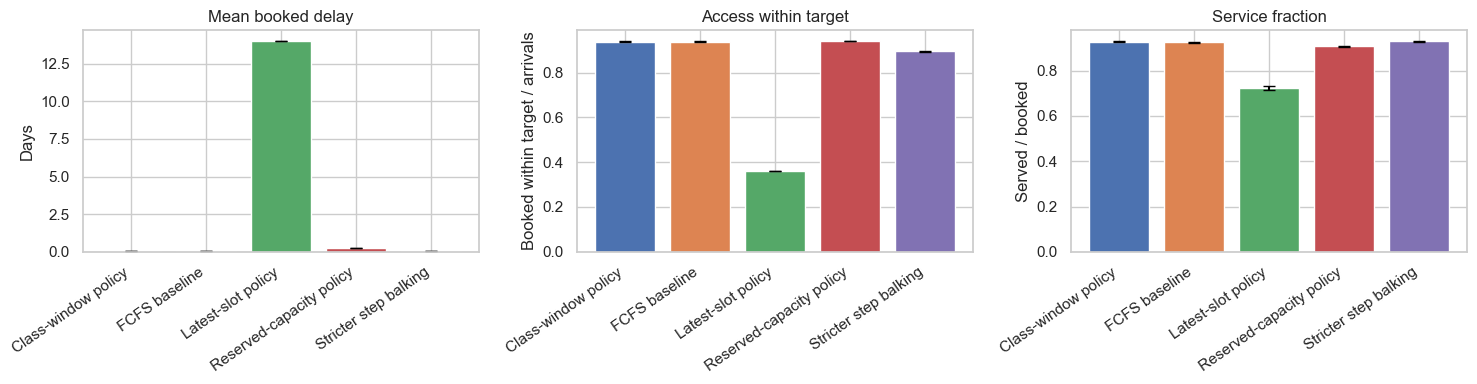

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [
    ("aggregate_mean_delay", "Mean booked delay", "Days"),
    ("booked_within_access_target_per_arrival", "Access within target", "Booked within target / arrivals"),
    ("served_per_booked", "Service fraction", "Served / booked"),
]
palette = sns.color_palette(n_colors=len(comparison_df["setup"].unique()))

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    plot_df = comparison_bootstrap[comparison_bootstrap["metric"] == metric].sort_values("setup")
    x_positions = list(range(len(plot_df)))
    ax.bar(x_positions, plot_df["mean"], color=palette)
    yerr = [plot_df["mean"] - plot_df["ci_lower"], plot_df["ci_upper"] - plot_df["mean"]]
    ax.errorbar(x_positions, plot_df["mean"], yerr=yerr, fmt="none", ecolor="black", capsize=4)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions, plot_df["setup"], rotation=35, ha="right")

plt.tight_layout()


In [5]:
class_bootstrap.sort_values(["metric", "setup", "label"])


,setup,label,metric,replications,mean,sd,ci_lower,ci_upper
1,Class-window policy,class_1 (MRI-like),booked_within_access_target_per_arrival,10,0.949632,0.002722,0.948038,0.951288
4,Class-window policy,class_2 (mental-health-like),booked_within_access_target_per_arrival,10,0.922168,0.003526,0.920066,0.924289
7,FCFS baseline,class_1 (MRI-like),booked_within_access_target_per_arrival,10,0.949168,0.002950,0.947419,0.950910
10,FCFS baseline,class_2 (mental-health-like),booked_within_access_target_per_arrival,10,0.921181,0.003300,0.919218,0.923154
13,Latest-slot policy,class_1 (MRI-like),booked_within_access_target_per_arrival,10,0.402497,0.006452,0.399122,0.406700
16,Latest-slot policy,class_2 (mental-health-like),booked_within_access_target_per_arrival,10,0.300607,0.008597,0.295396,0.305175
19,Reserved-capacity policy,class_1 (MRI-like),booked_within_access_target_per_arrival,10,0.951315,0.002972,0.949634,0.953019
22,Reserved-capacity policy,class_2 (mental-health-like),booked_within_access_target_per_arrival,10,0.923504,0.004107,0.920911,0.925732
25,Stricter step balking,class_1 (MRI-like),booked_within_access_target_per_arrival,10,0.903154,0.005203,0.900037,0.906198
28,Stricter step balking,class_2 (mental-health-like),booked_within_access_target_per_arrival,10,0.880924,0.007029,0.876637,0.884762
